In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
# Print the folder name, not the absolute path: the notebooks are
# committed with their outputs, and a machine path would be
# baked in and go stale.
print('working directory:', os.path.basename(os.getcwd()))

working directory: tk_learning


# Lesson 1 — Forward simulation. No data, no fitting, no statistics

The point of this lesson is that a toxicokinetic model is just a curve
with a few knobs. Before you try to learn the knobs from data, you should
know by feel what each one does to the curve.


```text
dC/dt = -k*C,  C(0) = dose/Vd     =>     C(t) = (dose/Vd)*exp(-k*t)
```

Three knobs:

```text
dose  how much went in        -> scales the whole curve up and down
Vd    how far it spreads      -> scales the whole curve up and down
k     how fast it comes out   -> changes the SHAPE
```

In [2]:
import numpy as np

import plotting as P
from tk import iv_1comp, half_life, clearance, steady_state

P.setup()

## A. One curve, printed as a table. Read it before looking at any plot.

In [3]:
dose, Vd, k = 10.0, 0.18, 0.06        # L/kg, 1/day -- roughly real values

print(f"   C(0)       = dose/Vd = {dose}/{Vd} = {dose/Vd:.1f} mg/L")
print(f"   half-life  = ln2/k   = {half_life(k):.1f} days")
print(f"   clearance  = k*Vd    = {clearance(k, Vd):.4f} L/kg/day\n")

print("   day     C (mg/L)    fraction of C(0)   half-lives elapsed")
for t in [0, 11.55, 23.1, 34.7, 46.2, 100]:
    C = iv_1comp(t, dose, Vd, k)
    print(f"   {t:6.1f}  {C:9.2f}   {C/(dose/Vd):14.3f}   {t*k/np.log(2):14.2f}")

   C(0)       = dose/Vd = 10.0/0.18 = 55.6 mg/L
   half-life  = ln2/k   = 11.6 days
   clearance  = k*Vd    = 0.0108 L/kg/day

   day     C (mg/L)    fraction of C(0)   half-lives elapsed
      0.0      55.56            1.000             0.00
     11.6      27.78            0.500             1.00
     23.1      13.89            0.250             2.00
     34.7       6.93            0.125             3.00
     46.2       3.47            0.063             4.00
    100.0       0.14            0.002             8.66


Every half-life the concentration halves, whatever it started at.
That is the defining property of FIRST-ORDER elimination: the rate of
removal is proportional to how much is there, so the FRACTION removed
per unit time is constant.

## B. Which knob changes the shape?

In [4]:
print(f"   {'case':28s} {'C(0)':>8s} {'C(30)':>8s} {'ratio':>8s} {'t1/2':>7s}")
for label, d, v, kk in [
    ("baseline",                 10.0, 0.18, 0.06),
    ("dose x2",                  20.0, 0.18, 0.06),
    ("Vd x2",                    10.0, 0.36, 0.06),
    ("k x2  (faster clearing)",  10.0, 0.18, 0.12),
]:
    c0, c30 = iv_1comp(0, d, v, kk), iv_1comp(30, d, v, kk)
    print(f"   {label:28s} {c0:8.1f} {c30:8.2f} {c30/c0:8.3f} {half_life(kk):7.1f}")

   case                             C(0)    C(30)    ratio    t1/2
   baseline                         55.6     9.18    0.165    11.6
   dose x2                         111.1    18.37    0.165    11.6
   Vd x2                            27.8     4.59    0.165    11.6
   k x2  (faster clearing)          55.6     1.52    0.027     5.8


dose and Vd move C(0) but leave the RATIO C(30)/C(0) untouched --
they slide the curve vertically. Only k changes the ratio.

This is why a half-life can be measured from a decay curve without
ever knowing the dose or the volume: the slope of log C against time
is -k, and nothing else enters it. It is also why Vd is the weak link
in any method that computes half-life from a measured clearance
instead (see ../literature/SYNTHESIS.md section 2).

## C. Repeated dosing: accumulation and steady state

In [5]:
dose_rate = 0.1            # mg/kg/day, every day
CL = clearance(k, Vd)
Css = steady_state(dose_rate, CL)
print(f"   dose rate {dose_rate} mg/kg/day, CL {CL:.4f} L/kg/day")
print(f"   steady state Css = rate/CL = {Css:.2f} mg/L   (Vd does not appear)\n")

C = 0.0
print("   day    C (mg/L)   % of steady state")
for day in range(1, 121):
    C = C * np.exp(-k) + dose_rate / Vd          # dose, then decay 1 day
    if day in (1, 5, 12, 23, 35, 46, 60, 90, 120):
        print(f"   {day:4d}  {C:9.2f}   {100*C/Css:14.0f}%")

   dose rate 0.1 mg/kg/day, CL 0.0108 L/kg/day
   steady state Css = rate/CL = 9.26 mg/L   (Vd does not appear)

   day    C (mg/L)   % of steady state
      1       0.56                6%
      5       2.47               27%
     12       4.90               53%
     23       7.14               77%
     35       8.37               90%
     46       8.94               97%
     60       9.28              100%
     90       9.50              103%
    120       9.53              103%


The printed value is the PEAK just after each day's dose, so it
settles a few percent above Css; the trough sits the same amount
below, and the average is Css exactly. The continuous-infusion
formula describes the average, not the peak.

Accumulation stops when input equals output. It takes about 4-5
half-lives to get within a few percent of Css, whatever the dose.
For PFOA in humans (half-life ~3 years) that is 12-15 years -- which
is why human blood levels respond so slowly to changes in exposure.

## D. The same three facts, as pictures

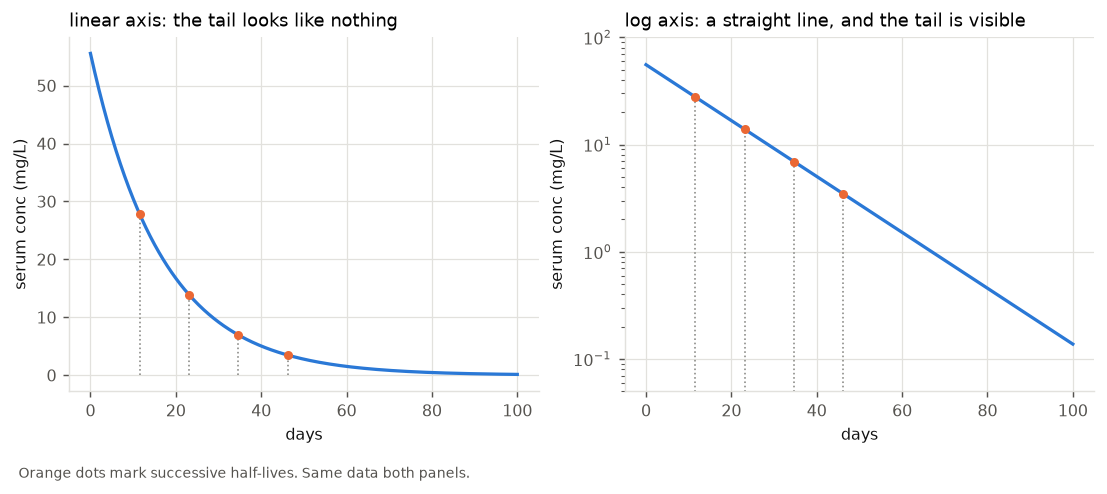

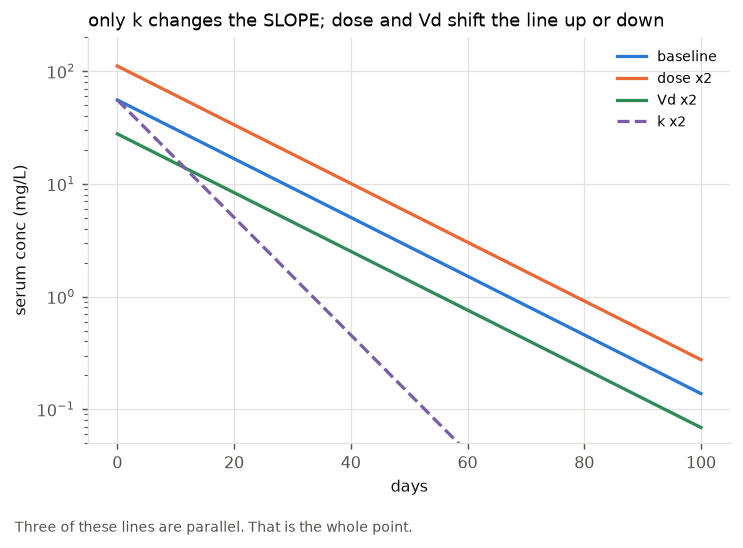

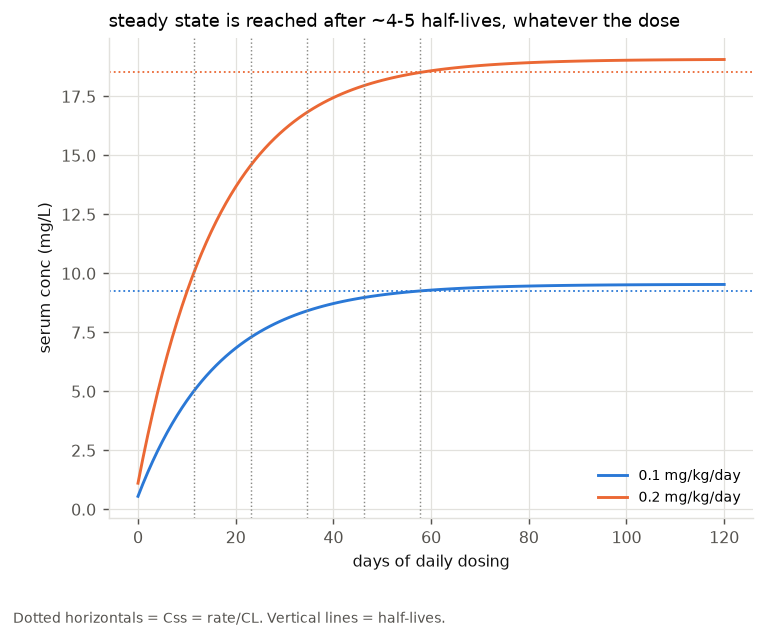

'figures/01_steady_state.png'

In [6]:
import matplotlib.pyplot as plt

# D1 -- the same curve on a linear and a log axis.
grid = np.linspace(0, 100, 600)
C = iv_1comp(grid, 10.0, 0.18, 0.06)
fig, (a, b) = plt.subplots(1, 2, figsize=(8.4, 3.4), constrained_layout=True)
for ax, logy in [(a, False), (b, True)]:
    P.model_line(ax, grid, C, label="C(t)")
    for n in range(1, 5):                      # mark each half-life
        th = n * half_life(0.06)
        ax.plot([th, th], [0 if not logy else 1e-3, iv_1comp(th, 10.0, 0.18, 0.06)],
                color=P.GREY, lw=0.9, ls=":")
        ax.plot(th, iv_1comp(th, 10.0, 0.18, 0.06), "o", color=P.ORANGE, ms=4)
    ax.set_xlabel("days")
    if logy:
        ax.set_yscale("log")
        ax.set_ylim(0.05, 100)
    ax.set_ylabel("serum conc (mg/L)")
a.set_title("linear axis: the tail looks like nothing")
b.set_title("log axis: a straight line, and the tail is visible")
P.save(fig, "01_linear_vs_log.png",
       "Orange dots mark successive half-lives. Same data both panels.")

# D2 -- which knob changes the shape.
fig, ax = plt.subplots(figsize=(5.6, 3.8), constrained_layout=True)
for (label, d, v, kk), col in zip(
        [("baseline", 10.0, 0.18, 0.06), ("dose x2", 20.0, 0.18, 0.06),
         ("Vd x2", 10.0, 0.36, 0.06), ("k x2", 10.0, 0.18, 0.12)], P.CYCLE):
    P.model_line(ax, grid, iv_1comp(grid, d, v, kk), label=label, color=col,
                 ls="--" if label == "k x2" else "-")
ax.set(yscale="log", xlabel="days", ylabel="serum conc (mg/L)", ylim=(0.05, 200))
ax.set_title("only k changes the SLOPE; dose and Vd shift the line up or down")
ax.legend()
P.save(fig, "01_which_knob.png",
       "Three of these lines are parallel. That is the whole point.")

# D3 -- accumulation towards steady state.
days = np.arange(0, 121)
for rate, col in [(0.1, P.BLUE), (0.2, P.ORANGE)]:
    conc, c = [], 0.0
    for _ in days:
        c = c * np.exp(-0.06) + rate / 0.18
        conc.append(c)
    plt.plot(days, conc, color=col, lw=1.6, label=f"{rate} mg/kg/day")
    plt.axhline(steady_state(rate, clearance(0.06, 0.18)), color=col,
                lw=1, ls=":")
for n in (1, 2, 3, 4, 5):
    plt.axvline(n * half_life(0.06), color=P.GREY, lw=0.8, ls=":")
plt.gca().set(xlabel="days of daily dosing", ylabel="serum conc (mg/L)")
plt.gca().set_title("steady state is reached after ~4-5 half-lives, whatever the dose")
plt.legend()
P.save(plt.gcf(), "01_steady_state.png",
       "Dotted horizontals = Css = rate/CL. Vertical lines = half-lives.")

# ----------------------------------------------------------------------
# QUESTIONS -- answer these before moving on
# ----------------------------------------------------------------------

### Questions

1. A chemical has a half-life of 5 days. What fraction is left after 15 days? Check with iv_1comp.
1. Two chemicals have the same half-life, but one has Vd = 0.1 L/kg and the other Vd = 1.0 L/kg. Which has the higher clearance? Which reaches a higher steady state on the same daily dose?
1. You double someone's daily intake. By what factor does their eventual steady-state level change? Does the answer depend on k?
1. PFOA in male rats has a half-life of ~13 days; in humans ~3 years. Same dose rate per kg. How much higher is the human steady state?

### Exercises

a. Modify section A to use PFHxA in male rats: half-life 0.095 days.
How many days of sampling would you need to see the decay?
c. Redraw 01_which_knob.png on a LINEAR y-axis. Can you still see
which curves are parallel? That is why PK is done in logs.
EXERCISES (continued)
b. In section C, change the dose to every 7 days instead of daily,
keeping the same average rate. Does Css change? Does the
peak-to-trough swing change? Which one matters for toxicity?